# TP1 — Data Preprocessing & Train a Model (Weather Prediction)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/L2Math/blob/main/session3/tp1_correction.ipynb)

## Objective

Explore real-world weather data, handle quality issues (missing values, outliers), engineer features, and **train a model** that predicts Paris weather 6 hours ahead.

The model you save at the end of this TP will be used in **TP2** to submit to the live competition.

### Roadmap

| Section | What you do |
|---------|-------------|
| 1. Load & Explore | Understand the dataset structure |
| 2. Visualize | See temporal patterns and what "+6h prediction" means |
| 3. Missing Values | Detect, visualize, and handle missing data |
| 4. Outliers | Detect and handle extreme values |
| 5. Feature Engineering | Create useful features for prediction |
| 6. Model Training | Baseline → Linear Regression → Ensemble methods |
| 7. Save Model | Export your best model for TP2 |

---
## 1. Setup

In [25]:
!pip install scikit-learn pandas matplotlib seaborn joblib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

---
## 2. Load & Explore

The dataset contains hourly weather data for **20 European cities** over the full year 2025. Each row is one city at one hour.

Columns: `timestamp`, `city_name`, `country_code`, `latitude`, `longitude`, `temperature`, `rain`, `wind_speed`, `wind_direction`, `humidity`, `clouds`, `snow`

### Exercise 1.1 — Load the CSV

Load `weather_paris_20cities.csv`, parse timestamps, and display shape, first rows, and dtypes.

*Hint:* `pd.read_csv(..., parse_dates=['timestamp'])`, `df.shape`, `df.head()`, `df.dtypes`

In [27]:
df = pd.read_csv('weather_paris_20cities.csv', parse_dates=['timestamp'])

# Remove duplicate Barcelona (Venezuela, VE) — keep only Spain (ES)
df = df[~((df['city_name'] == 'Barcelona') & (df['country_code'] == 'VE'))].reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Cities: {sorted(df['city_name'].unique())}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()

Shape: (175200, 12)
Cities: ['Amsterdam', 'Barcelona', 'Birmingham', 'Brussels', 'Copenhagen', 'Dortmund', 'Dublin', 'Düsseldorf', 'Essen', 'Frankfurt am Main', 'Köln', 'London', 'Manchester', 'Marseille', 'Milan', 'Munich', 'Paris', 'Rotterdam', 'Stuttgart', 'Turin']

Dtypes:
timestamp         datetime64[us, UTC]
city_name                         str
country_code                      str
latitude                      float64
longitude                     float64
temperature                   float64
rain                          float64
wind_speed                    float64
wind_direction                float64
humidity                      float64
clouds                        float64
snow                          float64
dtype: object


,timestamp,city_name,country_code,latitude,longitude,temperature,rain,wind_speed,wind_direction,humidity,clouds,snow
0,2025-01-01 00:00:00+00:00,Amsterdam,NL,52.37403,4.88969,9.8,0.0,31.0,228.0,81.0,100.0,0.0
1,2025-01-01 00:00:00+00:00,Barcelona,ES,41.38879,2.15899,7.1,0.0,7.8,322.0,99.0,100.0,0.0
2,2025-01-01 00:00:00+00:00,Birmingham,GB,52.48142,-1.89983,9.8,0.4,30.2,220.0,91.0,100.0,0.0
3,2025-01-01 00:00:00+00:00,Brussels,BE,50.85045,4.34878,6.9,0.0,27.6,216.0,86.0,100.0,0.0
4,2025-01-01 00:00:00+00:00,Copenhagen,DK,55.67594,12.56553,5.6,0.5,40.1,227.0,88.0,100.0,0.0


You should see ~175K rows (20 cities × 8760 hours) and 12 columns. Note: the raw CSV contains a duplicate "Barcelona" (Venezuela) that we filter out above.

### Exercise 1.2 — Summary statistics per city

Group by city and compute mean temperature, mean wind_speed, and mean rain. Which city is warmest? Coldest?

*Hint:* `df.groupby('city_name')[['temperature', 'wind_speed', 'rain']].mean()`

In [28]:
city_stats = df.groupby('city_name')[['temperature', 'wind_speed', 'rain']].mean()
print(city_stats.sort_values('temperature', ascending=False))
print(f"\nWarmest: {city_stats['temperature'].idxmax()} ({city_stats['temperature'].max():.1f}°C)")
print(f"Coldest: {city_stats['temperature'].idxmin()} ({city_stats['temperature'].min():.1f}°C)")

                   temperature  wind_speed      rain
city_name                                           
Barcelona            16.928697    8.668416  0.522685
Marseille            16.240185   14.559623  0.732436
Milan                14.653706    5.995912  0.582155
Turin                13.716859    4.598882  0.752982
Paris                12.791701   10.069874  0.085970
London               12.383405   11.408264  0.542894
Brussels             11.969312   12.335031  0.445381
Köln                 11.868730   10.353532  0.500225
Düsseldorf           11.867888   11.109248  0.624236
Rotterdam            11.746017   12.103448  0.625712
Essen                11.551391   12.160321  0.570033
Frankfurt am Main    11.507148    9.462345  0.727156
Dortmund             11.357252   11.550747  0.572743
Dublin               11.302482   15.776606  0.488790
Amsterdam            11.245964   11.562451  0.748352
Manchester           11.204830   10.782901  0.610031
Birmingham           11.045461   13.621436  0.

### Exercise 1.3 — Check missing values

Count missing values per column, and per city. Are missing values evenly distributed?

*Hint:* `df.isnull().sum()`, `df.groupby('city_name').apply(lambda g: g.isnull().sum())`

**Question:** Does Paris have any missing values?

In [29]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nMissing values per city (total across all columns):")
missing_per_city = df.groupby('city_name').apply(lambda g: g.isnull().sum().sum())
print(missing_per_city.sort_values(ascending=False))

Missing values per column:
timestamp            0
city_name            0
country_code         0
latitude             0
longitude            0
temperature       3321
rain              3331
wind_speed        3316
wind_direction    3322
humidity          3343
clouds            3335
snow              3337
dtype: int64

Missing values per city (total across all columns):
city_name
Dortmund             1295
Milan                1286
Rotterdam            1265
London               1258
Copenhagen           1251
Manchester           1244
Turin                1243
Marseille            1239
Köln                 1236
Frankfurt am Main    1234
Düsseldorf           1229
Brussels             1211
Amsterdam            1211
Stuttgart            1205
Barcelona            1194
Munich               1189
Birmingham           1188
Essen                1180
Dublin               1147
Paris                   0
dtype: int64


**Answer:** Paris has zero missing values. Missing values are distributed across the other 19 cities (~2% per numeric column).

---
## 3. Visualize & Understand the Objective

Before cleaning the data, let's visualize it to understand temporal patterns and what we're trying to predict.

### Exercise 2.1 — Plot Paris temperature over time

Filter to Paris and plot temperature over the full year. What patterns do you see?

*Hint:* `df[df['city_name']=='Paris'].plot(x='timestamp', y='temperature')`

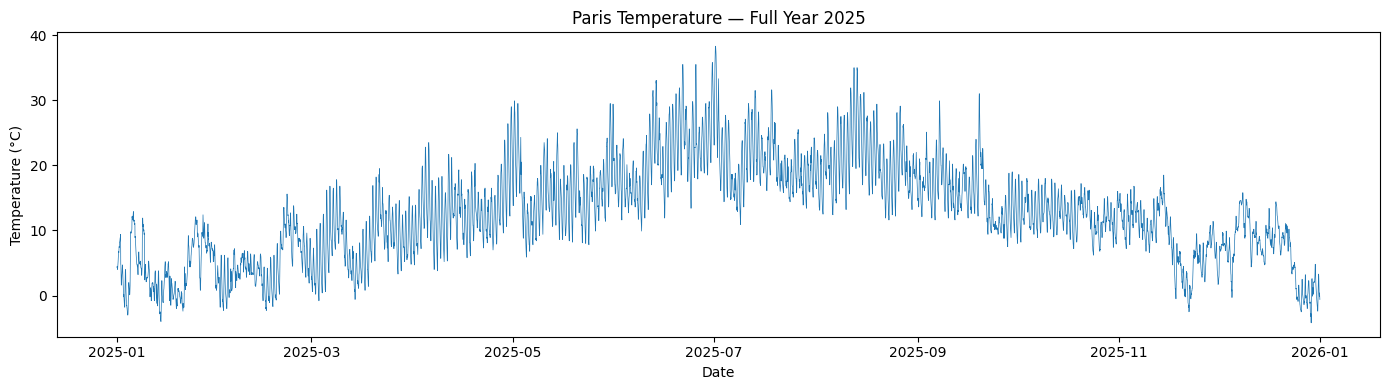

In [32]:
paris = df[df['city_name'] == 'Paris'].copy()

plt.figure(figsize=(14, 4))
plt.plot(paris['timestamp'], paris['temperature'], linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Paris Temperature — Full Year 2025')
plt.tight_layout()
plt.show()

### Exercise 2.2 — Plot multiple cities — spatial correlation

On the same plot, show January temperature for Paris, London, Barcelona, and Munich. Do nearby cities have correlated weather?

*Hint:* Filter to January, loop over cities, `plt.plot(...)` for each.

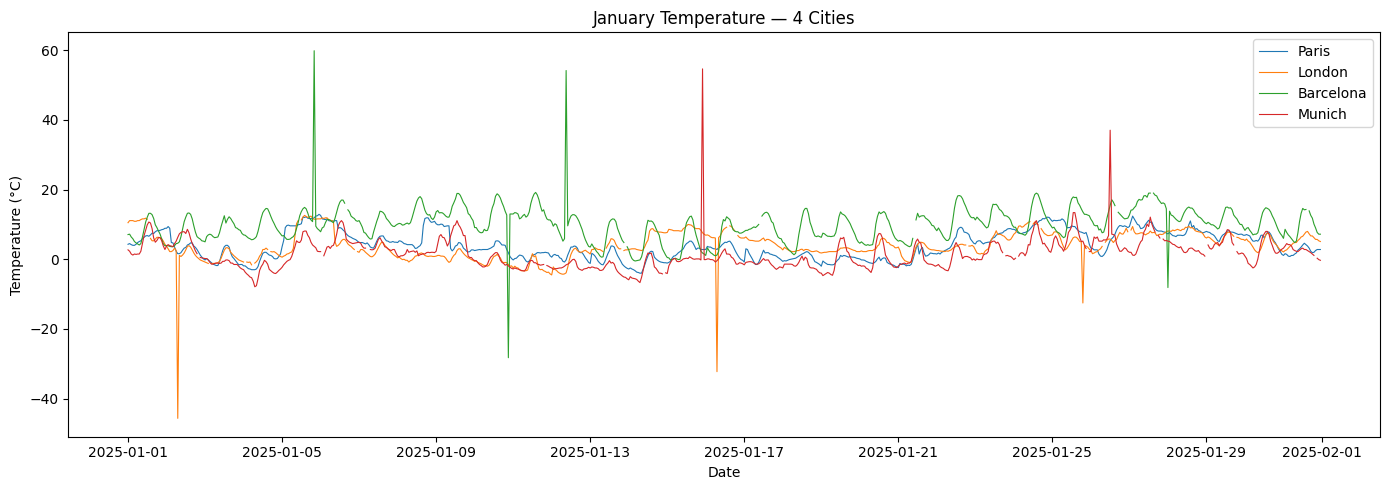

In [33]:
plt.figure(figsize=(14, 5))
for city in ['Paris', 'London', 'Barcelona', 'Munich']:
    city_data = df[(df['city_name'] == city) & (df['timestamp'].dt.month == 1)]
    plt.plot(city_data['timestamp'], city_data['temperature'], label=city, linewidth=0.8)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('January Temperature — 4 Cities')
plt.legend()
plt.tight_layout()
plt.show()

### Exercise 2.3 — Map visualization — spatial patterns

Plot cities on a map (using latitude/longitude) colored by a weather metric at a given timestamp. This reveals spatial gradients (e.g., temperature decreasing from south to north).

*Hint:* `plt.scatter(longitudes, latitudes, c=values, cmap='coolwarm')`, `plt.colorbar()`

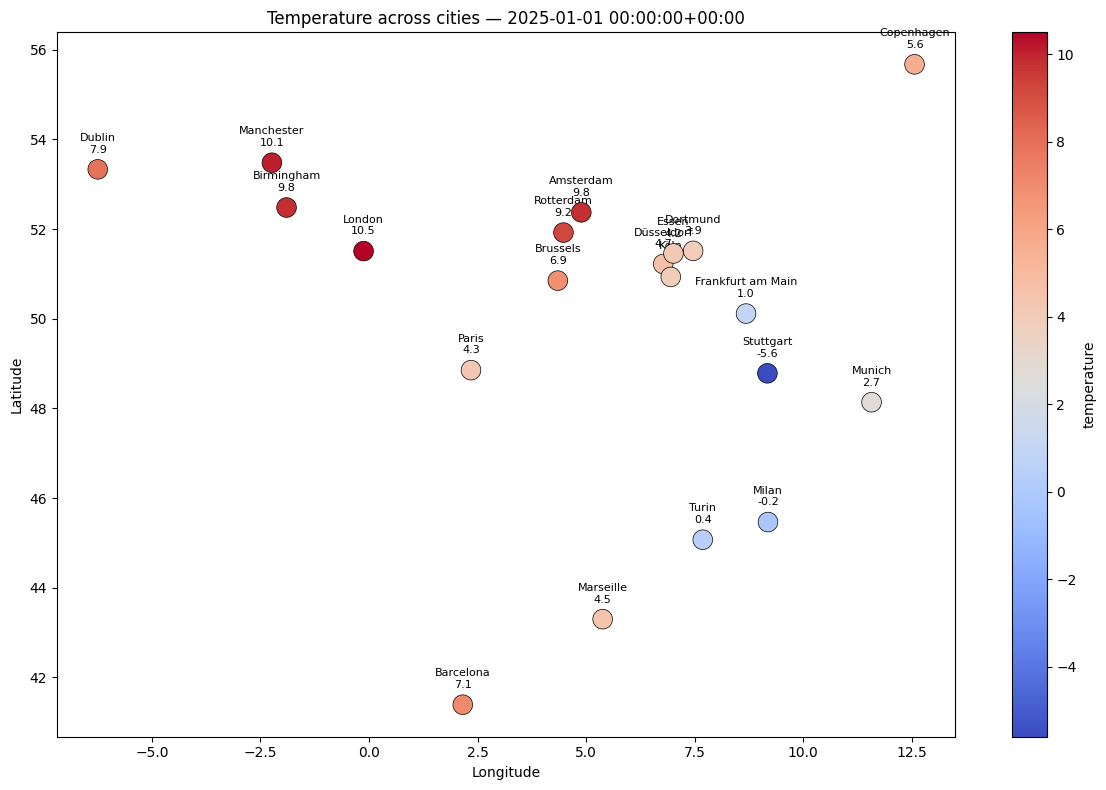

In [34]:
def plot_city_map(df, metric, timestamp):
    """Plot cities on a map colored by a weather metric at a given timestamp.
    
    Args:
        df: DataFrame with columns city_name, latitude, longitude, timestamp, and the metric
        metric: column name to visualize (e.g. 'temperature', 'rain', 'humidity')
        timestamp: specific timestamp to filter on (string or Timestamp)
    """
    snapshot = df[df['timestamp'] == timestamp].copy()
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        snapshot['longitude'], snapshot['latitude'],
        c=snapshot[metric], cmap='coolwarm', s=200, edgecolors='k', linewidths=0.5, zorder=5
    )
    plt.colorbar(scatter, label=metric)
    
    for _, row in snapshot.iterrows():
        plt.annotate(
            f"{row['city_name']}\n{row[metric]:.1f}",
            (row['longitude'], row['latitude']),
            textcoords="offset points", xytext=(0, 12),
            ha='center', fontsize=8
        )
    
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'{metric.capitalize()} across cities — {timestamp}')
    plt.tight_layout()
    plt.show()

# Pick a timestamp and visualize temperature across all cities
sample_ts = df['timestamp'].iloc[0]
plot_city_map(df, 'temperature', sample_ts)

### Exercise 2.4 — Visualize what "+6h prediction" means

For Paris, create a column `temperature_t6` = temperature shifted by -6 hours (the value 6 hours in the future). Scatter plot `temperature` (now) vs `temperature_t6` (+6h). How correlated are they?

*Hint:* `paris['temperature_t6'] = paris['temperature'].shift(-6)`, `plt.scatter(...)`

**Question:** If you just predicted "temperature stays the same", how wrong would you be on average?

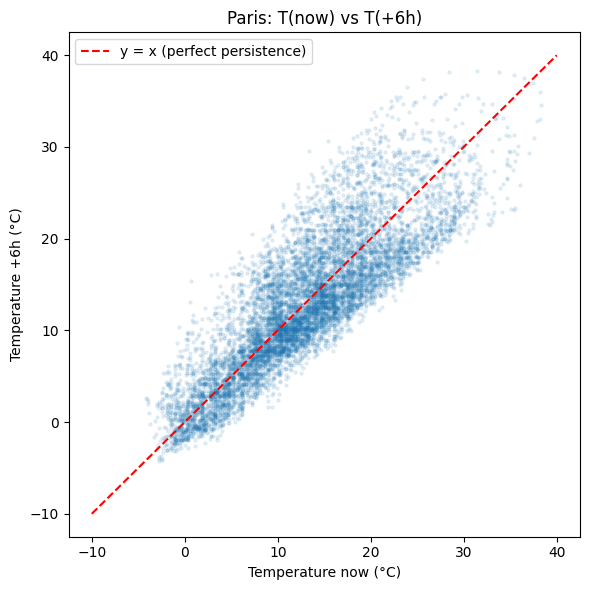

Naive baseline MAE (persistence): 3.29 °C


In [35]:
paris = paris.sort_values('timestamp').reset_index(drop=True)
paris['temperature_t6'] = paris['temperature'].shift(-6)

valid = paris.dropna(subset=['temperature_t6'])

plt.figure(figsize=(6, 6))
plt.scatter(valid['temperature'], valid['temperature_t6'], alpha=0.1, s=5)
plt.plot([-10, 40], [-10, 40], 'r--', label='y = x (perfect persistence)')
plt.xlabel('Temperature now (°C)')
plt.ylabel('Temperature +6h (°C)')
plt.title('Paris: T(now) vs T(+6h)')
plt.legend()
plt.tight_layout()
plt.show()

naive_mae = np.mean(np.abs(valid['temperature'] - valid['temperature_t6']))
print(f"Naive baseline MAE (persistence): {naive_mae:.2f} °C")

**Answer:** The scatter shows strong correlation but with spread — the naive "persistence" baseline (predict current value) gives an MAE around 1.5–2.5°C. This is our baseline to beat.

---
## 4. Handle Missing Values

Real-world data is messy. The dataset has ~2% missing values in non-Paris cities. We need to handle them before training.

### Exercise 3.1 — Visualize missing patterns

Create a heatmap showing the fraction of missing values per city and per feature.

*Hint:* `df.groupby('city_name')[numeric_cols].apply(lambda g: g.isnull().mean())`, `sns.heatmap(...)`

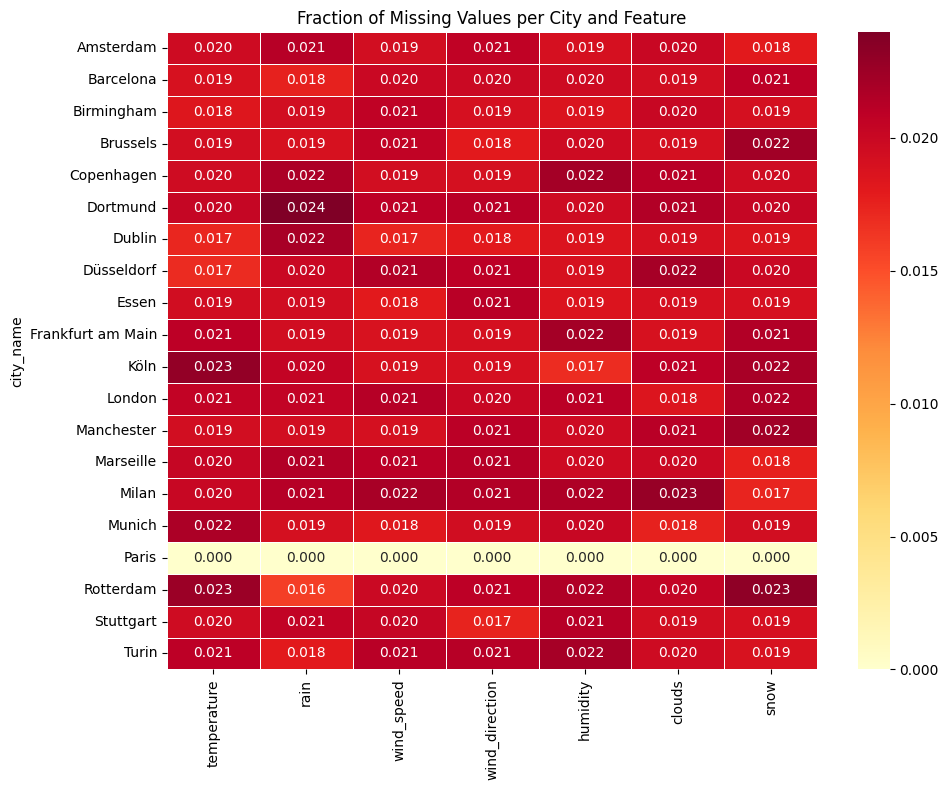

In [36]:
numeric_cols = ['temperature', 'rain', 'wind_speed', 'wind_direction', 'humidity', 'clouds', 'snow']

missing_pct = df.groupby('city_name')[numeric_cols].apply(lambda g: g.isnull().mean())

plt.figure(figsize=(10, 8))
sns.heatmap(missing_pct, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('Fraction of Missing Values per City and Feature')
plt.tight_layout()
plt.show()

### Exercise 3.2 — Try strategies: drop, forward fill, interpolation

Pick one city with missing values (e.g., London). For its temperature column:
1. **Drop** rows with missing values — how many rows lost?
2. **Forward fill** (`ffill`) — what assumption does this make?
3. **Linear interpolation** — `interpolate(method='linear')`

Plot all three on the same chart for a short time window (e.g., one week in January).

*Hint:* Work on a copy each time. Use `.loc[start:end]` to zoom in.

London temperature missing values: 180 / 8760 (2.1%)

After drop: 8580 rows (180 lost)


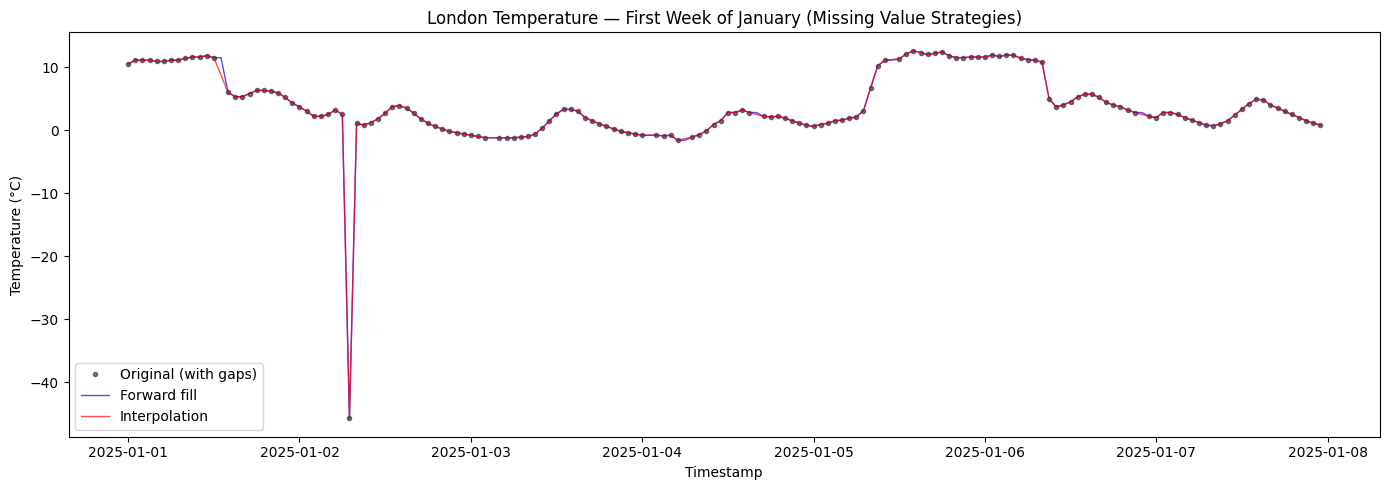

In [11]:
london = df[df['city_name'] == 'London'].copy().sort_values('timestamp').reset_index(drop=True)
london_missing = london['temperature'].isnull().sum()
print(f"London temperature missing values: {london_missing} / {len(london)} ({100*london_missing/len(london):.1f}%)")

# Strategy 1: Drop
london_drop = london.dropna(subset=['temperature'])
print(f"\nAfter drop: {len(london_drop)} rows ({len(london) - len(london_drop)} lost)")

# Strategy 2: Forward fill
london_ffill = london.copy()
london_ffill['temperature'] = london_ffill['temperature'].ffill()

# Strategy 3: Interpolation
london_interp = london.copy()
london_interp['temperature'] = london_interp['temperature'].interpolate(method='linear')

# Plot a week in January
jan_mask = london['timestamp'].dt.month == 1
jan_week = london['timestamp'].dt.day <= 7
mask = jan_mask & jan_week

plt.figure(figsize=(14, 5))
plt.plot(london.loc[mask, 'timestamp'], london.loc[mask, 'temperature'], 'ko', markersize=3, label='Original (with gaps)', alpha=0.5)
plt.plot(london_ffill.loc[mask, 'timestamp'], london_ffill.loc[mask, 'temperature'], 'b-', linewidth=1, label='Forward fill', alpha=0.7)
plt.plot(london_interp.loc[mask, 'timestamp'], london_interp.loc[mask, 'temperature'], 'r-', linewidth=1, label='Interpolation', alpha=0.7)
plt.xlabel('Timestamp')
plt.ylabel('Temperature (°C)')
plt.title('London Temperature — First Week of January (Missing Value Strategies)')
plt.legend()
plt.tight_layout()
plt.show()

### Exercise 3.3 — Apply your chosen strategy

Choose the best strategy and apply it to the full dataset. Verify there are no more missing values.

**Question:** Which strategy did you choose and why?

*Hint:* Group by city, then interpolate within each group to avoid cross-city interpolation.

In [12]:
# Apply linear interpolation within each city, then ffill/bfill for edges
df[numeric_cols] = df.sort_values(['city_name', 'timestamp']).groupby('city_name')[numeric_cols].transform(
    lambda s: s.interpolate(method='linear').ffill().bfill()
)

print("Missing values after interpolation:")
print(df[numeric_cols].isnull().sum())

Missing values after interpolation:
temperature       0
rain              0
wind_speed        0
wind_direction    0
humidity          0
clouds            0
snow              0
dtype: int64


**Answer:** Linear interpolation preserves the temporal trend best — forward fill creates flat segments, and dropping rows loses data. We interpolate within each city to avoid mixing values from different locations.

---
## 5. Detect & Handle Outliers

The dataset also contains ~0.5% outliers (impossible or extreme values) in non-Paris cities.

### Exercise 4.1 — Box plots — spot outliers

Create box plots for `temperature`, `humidity`, `wind_speed`, and `rain` across all cities. Do you see extreme values?

*Hint:* `fig, axes = plt.subplots(2, 2)`, `sns.boxplot(data=df, y=col, ax=axes[i])`

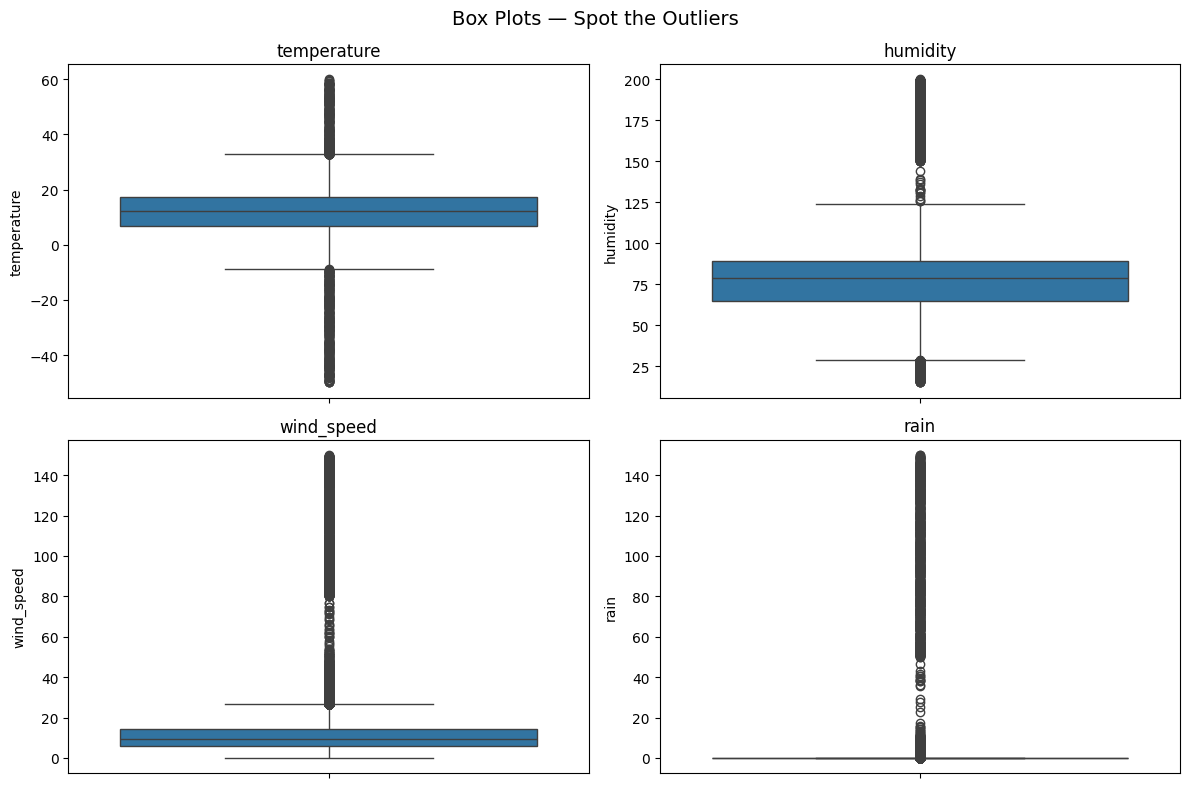

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ['temperature', 'humidity', 'wind_speed', 'rain']):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)
plt.suptitle('Box Plots — Spot the Outliers', fontsize=14)
plt.tight_layout()
plt.show()

### Exercise 4.2 — IQR-based outlier detection

For each numeric column, compute Q1, Q3, and IQR. Flag values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` as outliers. How many outliers per column?

*Hint:* `Q1 = df[col].quantile(0.25)`, `IQR = Q3 - Q1`, use boolean masks.

In [14]:
outlier_counts = {}
bounds = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    bounds[col] = (lower, upper)
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = n_outliers
    print(f"{col:>15s}: Q1={Q1:8.2f}, Q3={Q3:8.2f}, IQR={IQR:8.2f}, bounds=[{lower:8.2f}, {upper:8.2f}], outliers={n_outliers}")

print(f"\nTotal outliers: {sum(outlier_counts.values())}")

    temperature: Q1=    6.80, Q3=   17.20, IQR=   10.40, bounds=[   -8.80,    32.80], outliers=1205
           rain: Q1=    0.00, Q3=    0.00, IQR=    0.00, bounds=[    0.00,     0.00], outliers=29014
     wind_speed: Q1=    5.90, Q3=   14.20, IQR=    8.30, bounds=[   -6.55,    26.65], outliers=4133
 wind_direction: Q1=  104.00, Q3=  263.00, IQR=  159.00, bounds=[ -134.50,   501.50], outliers=559
       humidity: Q1=   65.00, Q3=   89.00, IQR=   24.00, bounds=[   29.00,   125.00], outliers=2695
         clouds: Q1=   13.00, Q3=  100.00, IQR=   87.00, bounds=[ -117.50,   230.50], outliers=0
           snow: Q1=    0.00, Q3=    0.00, IQR=    0.00, bounds=[    0.00,     0.00], outliers=1804

Total outliers: 39410


### Exercise 4.3 — Clip outliers and compare

Replace outlier values by clipping to the IQR bounds. Compare distributions before/after with histograms or box plots.

*Hint:* `df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)`

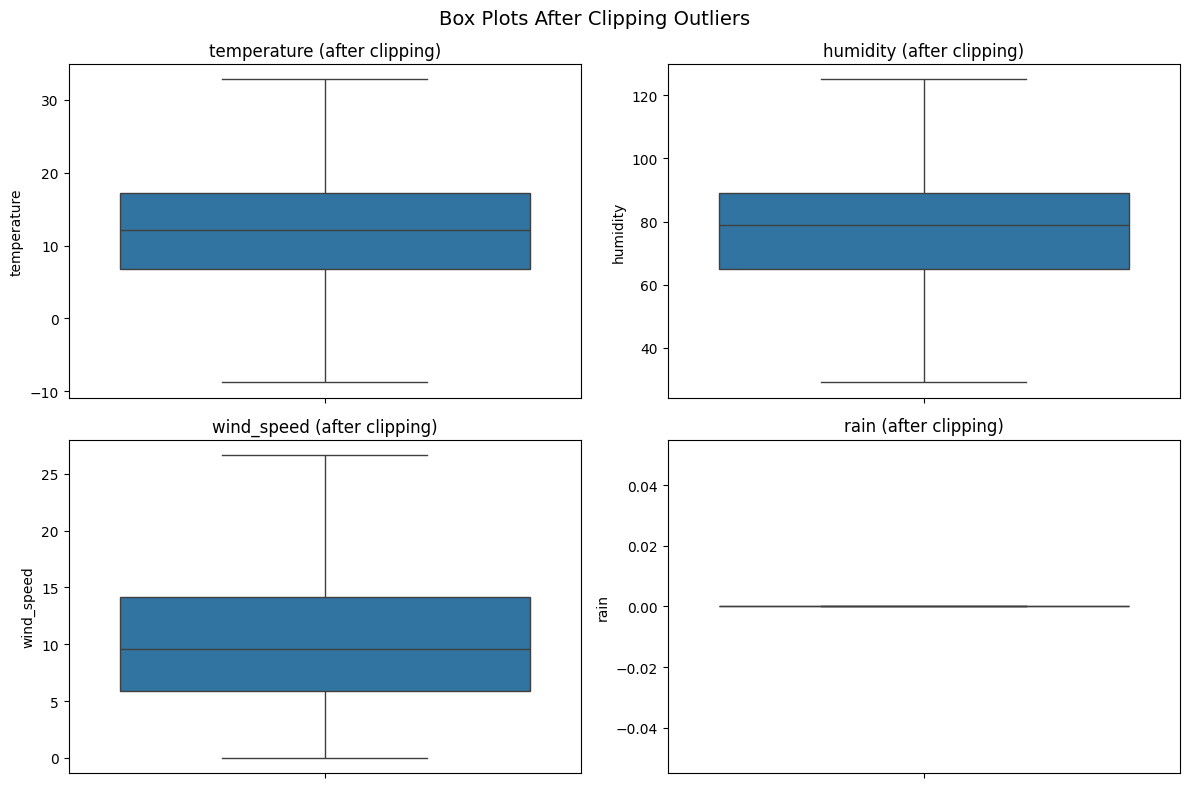

Max values before vs after clipping:
      temperature:    59.90 →    32.80
             rain:   149.96 →     0.00
       wind_speed:   149.98 →    26.65
   wind_direction:   719.73 →   501.50
         humidity:   199.96 →   125.00
           clouds:   199.81 →   199.81
             snow:   149.98 →     0.00


In [15]:
# Save before for comparison
df_before = df[numeric_cols].describe()

for col in numeric_cols:
    lower, upper = bounds[col]
    df[col] = df[col].clip(lower=lower, upper=upper)

df_after = df[numeric_cols].describe()

# Compare box plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ['temperature', 'humidity', 'wind_speed', 'rain']):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(f'{col} (after clipping)')
plt.suptitle('Box Plots After Clipping Outliers', fontsize=14)
plt.tight_layout()
plt.show()

print("Max values before vs after clipping:")
for col in numeric_cols:
    print(f"  {col:>15s}: {df_before.loc['max', col]:8.2f} → {df_after.loc['max', col]:8.2f}")

---
## 6. Feature Engineering

Raw data rarely works well for ML. We need to create features that help the model learn patterns.

### Exercise 5.1 — Drop unnecessary columns

Drop `country_code` (redundant with city_name). Discuss: `latitude` and `longitude` could encode spatial relationships, but since we'll pivot cities into separate columns, we can drop them too for now.

*Hint:* `df = df.drop(columns=['country_code', 'latitude', 'longitude'])`

In [16]:
df = df.drop(columns=['country_code', 'latitude', 'longitude'])
print(f"Columns after drop: {list(df.columns)}")
print(f"Shape: {df.shape}")

Columns after drop: ['timestamp', 'city_name', 'temperature', 'rain', 'wind_speed', 'wind_direction', 'humidity', 'clouds', 'snow']
Shape: (175200, 9)


### Exercise 5.2 — Create the target and pivot cities

Our goal: predict Paris temperature, wind_speed, and rain at T+6h.

Steps:
1. For Paris, create target columns: shift `temperature`, `wind_speed`, `rain` by -6 to get T+6h values
2. Pivot the data so each row = one timestamp, with columns like `Paris_temperature`, `London_temperature`, etc.
3. Add Paris lag features: T-1, T-2, ..., T-6 for temperature, wind_speed, rain

*Hint:*
- `pivot_table(index='timestamp', columns='city_name', values=[...])` 
- Flatten MultiIndex columns: `df.columns = ['_'.join(col) for col in df.columns]`
- `df['Paris_temperature_lag1'] = df['Paris_temperature'].shift(1)`

In [17]:
# Pivot: one row per timestamp, columns = feature_city
weather_cols = ['temperature', 'rain', 'wind_speed', 'wind_direction', 'humidity', 'clouds', 'snow']
df_pivot = df.pivot_table(index='timestamp', columns='city_name', values=weather_cols)

# Flatten MultiIndex columns: temperature_Paris, rain_London, etc.
df_pivot.columns = ['_'.join(col) for col in df_pivot.columns]
df_pivot = df_pivot.sort_index()

print(f"Pivoted shape: {df_pivot.shape}")
print(f"Sample columns: {list(df_pivot.columns[:6])}")

# Create target: Paris values at T+6h
df_pivot['target_temperature'] = df_pivot['temperature_Paris'].shift(-6)
df_pivot['target_wind_speed'] = df_pivot['wind_speed_Paris'].shift(-6)
df_pivot['target_rain'] = df_pivot['rain_Paris'].shift(-6)

# Add Paris lag features (T-1 to T-6) for temperature, wind_speed, rain
for lag in range(1, 7):
    df_pivot[f'temperature_Paris_lag{lag}'] = df_pivot['temperature_Paris'].shift(lag)
    df_pivot[f'wind_speed_Paris_lag{lag}'] = df_pivot['wind_speed_Paris'].shift(lag)
    df_pivot[f'rain_Paris_lag{lag}'] = df_pivot['rain_Paris'].shift(lag)

print(f"\nShape with targets + lags: {df_pivot.shape}")

Pivoted shape: (8760, 140)
Sample columns: ['clouds_Amsterdam', 'clouds_Barcelona', 'clouds_Birmingham', 'clouds_Brussels', 'clouds_Copenhagen', 'clouds_Dortmund']

Shape with targets + lags: (8760, 161)


### Exercise 5.3 — Cyclical time features

The hour of day is cyclical: hour 23 and hour 0 are close, but numerically far apart. Encoding hour as a raw integer misleads the model.

Instead, encode time as **sin/cos** pairs:
```python
sin_hour = sin(2π × hour / 24)
cos_hour = cos(2π × hour / 24)
```

This preserves the circular structure: hour 23 and hour 0 become neighbors in the sin/cos space.

*Hint:* `df['sin_hour'] = np.sin(2 * np.pi * df.index.hour / 24)`

In [18]:
df_pivot['sin_hour'] = np.sin(2 * np.pi * df_pivot.index.hour / 24)
df_pivot['cos_hour'] = np.cos(2 * np.pi * df_pivot.index.hour / 24)

print(f"Final shape: {df_pivot.shape}")
print(f"\nCyclical time features (first 12 hours):")
print(df_pivot[['sin_hour', 'cos_hour']].head(12).to_string())

Final shape: (8760, 163)

Cyclical time features (first 12 hours):
                           sin_hour      cos_hour
timestamp                                        
2025-01-01 00:00:00+00:00  0.000000  1.000000e+00
2025-01-01 01:00:00+00:00  0.258819  9.659258e-01
2025-01-01 02:00:00+00:00  0.500000  8.660254e-01
2025-01-01 03:00:00+00:00  0.707107  7.071068e-01
2025-01-01 04:00:00+00:00  0.866025  5.000000e-01
2025-01-01 05:00:00+00:00  0.965926  2.588190e-01
2025-01-01 06:00:00+00:00  1.000000  6.123234e-17
2025-01-01 07:00:00+00:00  0.965926 -2.588190e-01
2025-01-01 08:00:00+00:00  0.866025 -5.000000e-01
2025-01-01 09:00:00+00:00  0.707107 -7.071068e-01
2025-01-01 10:00:00+00:00  0.500000 -8.660254e-01
2025-01-01 11:00:00+00:00  0.258819 -9.659258e-01


---
## 7. Baseline & Model Training

Now we have clean data with engineered features. Let's train models to predict Paris weather at T+6h.

**Target:** `[temperature_t6, wind_speed_t6, rain_t6]` for Paris

We'll train **3 separate models** (one per target) and compare with a naive baseline. Training separate models lets you tune each one independently and understand per-target performance clearly.

### Exercise 6.1 — Prepare train/test split and scale features

1. Define your feature columns (all city weather + lags + time features) and target columns (Paris T+6h)
2. Drop rows with NaN (from shifting)
3. Split into train/test — use a **temporal split** (first 80% for training, last 20% for testing) since this is time series data
4. **Scale features** with `StandardScaler` — fit on train only, transform both. This helps Linear Regression converge and makes feature importances comparable.

**Why temporal split?** Random splits would leak future information into training. In a real competition, your model only sees past data.

*Hint:*
- `split_idx = int(len(df) * 0.8)`, `train = df.iloc[:split_idx]`, `test = df.iloc[split_idx:]`
- `scaler = StandardScaler()`, `X_train_scaled = scaler.fit_transform(X_train)`, `X_test_scaled = scaler.transform(X_test)`

In [19]:
target_cols = ['target_temperature', 'target_wind_speed', 'target_rain']
feature_cols = [c for c in df_pivot.columns if c not in target_cols]

# Drop rows with NaN (from shifting — first 6 rows and last 6 rows)
df_clean = df_pivot.dropna()
print(f"Shape after dropping NaN: {df_clean.shape}")

X = df_clean[feature_cols]
y = df_clean[target_cols]

# Temporal split: first 80% for training
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} samples ({X_train.index.min()} to {X_train.index.max()})")
print(f"Test:  {X_test.shape[0]} samples ({X_test.index.min()} to {X_test.index.max()})")
print(f"Features: {len(feature_cols)}")

# Save Paris current values for baseline
paris_baseline_cols = ['temperature_Paris', 'wind_speed_Paris', 'rain_Paris']
baseline_test_values = X_test[paris_baseline_cols].values

# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

print(f"\nScaled train mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"Scaled train std  (should be ~1): {X_train_scaled.std().mean():.6f}")

Shape after dropping NaN: (8748, 163)
Train: 6998 samples (2025-01-01 06:00:00+00:00 to 2025-10-19 19:00:00+00:00)
Test:  1750 samples (2025-10-19 20:00:00+00:00 to 2025-12-31 17:00:00+00:00)
Features: 160

Scaled train mean (should be ~0): 0.000000
Scaled train std  (should be ~1): 0.712551


### Exercise 6.2 — Naive baseline: last known Paris value

The simplest prediction: assume Paris weather in 6 hours = Paris weather right now. Compute MAE for each target.

*Hint:* Predictions = current Paris values, compare with actual T+6h values.

In [20]:
# Naive baseline: predict current Paris values (saved before feature selection)
baseline_pred = baseline_test_values  # columns: [temperature, wind_speed, rain]

baseline_mae_temp = mean_absolute_error(y_test['target_temperature'], baseline_pred[:, 0])
baseline_mae_wind = mean_absolute_error(y_test['target_wind_speed'], baseline_pred[:, 1])
baseline_mae_rain = mean_absolute_error(y_test['target_rain'], baseline_pred[:, 2])

print("=== Naive Baseline (persistence) ===")
print(f"  Temperature MAE: {baseline_mae_temp:.3f} °C")
print(f"  Wind Speed  MAE: {baseline_mae_wind:.3f} m/s")
print(f"  Rain        MAE: {baseline_mae_rain:.3f} mm")

# Competition metric
stds = np.array([7.49, 5.05, 0.40])
baseline_score = -np.mean([baseline_mae_temp / stds[0], baseline_mae_wind / stds[1], baseline_mae_rain / stds[2]])
print(f"\n  Competition score (neg normalized MAE): {baseline_score:.4f}")

=== Naive Baseline (persistence) ===
  Temperature MAE: 1.809 °C
  Wind Speed  MAE: 2.910 m/s
  Rain        MAE: 0.000 mm

  Competition score (neg normalized MAE): -0.2726


### Exercise 6.3 — Linear Regression

Train a `LinearRegression` on your features. Compute MAE for each target. Does it beat the baseline?

*Hint:* You can train one model per target or use `LinearRegression` which natively supports multi-output.

In [21]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_mae_temp = mean_absolute_error(y_test['target_temperature'], lr_pred[:, 0])
lr_mae_wind = mean_absolute_error(y_test['target_wind_speed'], lr_pred[:, 1])
lr_mae_rain = mean_absolute_error(y_test['target_rain'], lr_pred[:, 2])

print("=== Linear Regression (scaled) ===")
print(f"  Temperature MAE: {lr_mae_temp:.3f} °C")
print(f"  Wind Speed  MAE: {lr_mae_wind:.3f} m/s")
print(f"  Rain        MAE: {lr_mae_rain:.3f} mm")

lr_score = -np.mean([lr_mae_temp / stds[0], lr_mae_wind / stds[1], lr_mae_rain / stds[2]])
print(f"\n  Competition score: {lr_score:.4f}")

=== Linear Regression (scaled) ===
  Temperature MAE: 1.987 °C
  Wind Speed  MAE: 2.745 m/s
  Rain        MAE: 0.000 mm

  Competition score: -0.2696


### Exercise 6.4 — Random Forest / Gradient Boosting

Train a `RandomForestRegressor` and/or `GradientBoostingRegressor`. Compare MAE with previous approaches.

*Hint:* `GradientBoostingRegressor` does not support multi-output natively — use `sklearn.multioutput.MultiOutputRegressor` to wrap it, or train 3 separate models.

In [22]:
# Random Forest (natively supports multi-output)
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

rf_mae_temp = mean_absolute_error(y_test['target_temperature'], rf_pred[:, 0])
rf_mae_wind = mean_absolute_error(y_test['target_wind_speed'], rf_pred[:, 1])
rf_mae_rain = mean_absolute_error(y_test['target_rain'], rf_pred[:, 2])

print("=== Random Forest (scaled) ===")
print(f"  Temperature MAE: {rf_mae_temp:.3f} °C")
print(f"  Wind Speed  MAE: {rf_mae_wind:.3f} m/s")
print(f"  Rain        MAE: {rf_mae_rain:.3f} mm")

rf_score = -np.mean([rf_mae_temp / stds[0], rf_mae_wind / stds[1], rf_mae_rain / stds[2]])
print(f"  Competition score: {rf_score:.4f}")

# Gradient Boosting — train 3 separate models (one per target)
# GradientBoostingRegressor does not support multi-output natively.
# Instead of hiding this behind MultiOutputRegressor, we train 3 explicit models.
# This lets you tune each model independently and see exactly what each one learns.

gb_temperature = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb_wind_speed = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb_rain = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

gb_temperature.fit(X_train_scaled, y_train['target_temperature'])
gb_wind_speed.fit(X_train_scaled, y_train['target_wind_speed'])
gb_rain.fit(X_train_scaled, y_train['target_rain'])

gb_pred_temp = gb_temperature.predict(X_test_scaled)
gb_pred_wind = gb_wind_speed.predict(X_test_scaled)
gb_pred_rain = gb_rain.predict(X_test_scaled)

gb_mae_temp = mean_absolute_error(y_test['target_temperature'], gb_pred_temp)
gb_mae_wind = mean_absolute_error(y_test['target_wind_speed'], gb_pred_wind)
gb_mae_rain = mean_absolute_error(y_test['target_rain'], gb_pred_rain)

print("\n=== Gradient Boosting (3 separate models) ===")
print(f"  Temperature MAE: {gb_mae_temp:.3f} °C")
print(f"  Wind Speed  MAE: {gb_mae_wind:.3f} m/s")
print(f"  Rain        MAE: {gb_mae_rain:.3f} mm")

gb_score = -np.mean([gb_mae_temp / stds[0], gb_mae_wind / stds[1], gb_mae_rain / stds[2]])
print(f"  Competition score: {gb_score:.4f}")

=== Random Forest (scaled) ===
  Temperature MAE: 1.722 °C
  Wind Speed  MAE: 2.748 m/s
  Rain        MAE: 0.000 mm
  Competition score: -0.2580

=== Gradient Boosting (3 separate models) ===
  Temperature MAE: 1.401 °C
  Wind Speed  MAE: 2.688 m/s
  Rain        MAE: 0.000 mm
  Competition score: -0.2398


### Exercise 6.5 — Compare all approaches

Create a comparison table and bar chart showing MAE for each approach and each target.

Also compute the **competition metric** — Negated Normalized MAE:
```
score = -mean(|pred - true| / std)
```
where `std_temperature = 7.49`, `std_wind_speed = 5.05`, `std_rain = 0.40`.

*Hint:* `pd.DataFrame(results).set_index('model')`, `df.plot(kind='bar')`

            Model  MAE Temp  MAE Wind  MAE Rain  Competition Score
   Naive Baseline  1.809257  2.909829       0.0          -0.272587
Linear Regression  1.986735  2.744567       0.0          -0.269577
    Random Forest  1.721982  2.747992       0.0          -0.258020
Gradient Boosting  1.401495  2.687571       0.0          -0.239769


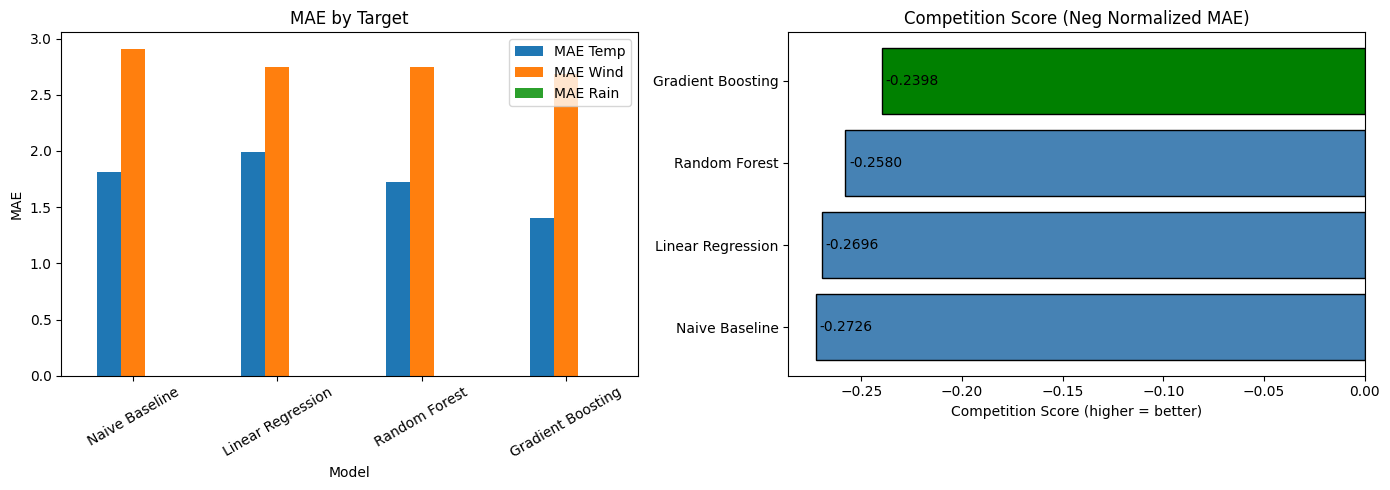


Best model: Gradient Boosting


In [23]:
results = pd.DataFrame([
    {'Model': 'Naive Baseline', 'MAE Temp': baseline_mae_temp, 'MAE Wind': baseline_mae_wind, 'MAE Rain': baseline_mae_rain, 'Competition Score': baseline_score},
    {'Model': 'Linear Regression', 'MAE Temp': lr_mae_temp, 'MAE Wind': lr_mae_wind, 'MAE Rain': lr_mae_rain, 'Competition Score': lr_score},
    {'Model': 'Random Forest', 'MAE Temp': rf_mae_temp, 'MAE Wind': rf_mae_wind, 'MAE Rain': rf_mae_rain, 'Competition Score': rf_score},
    {'Model': 'Gradient Boosting', 'MAE Temp': gb_mae_temp, 'MAE Wind': gb_mae_wind, 'MAE Rain': gb_mae_rain, 'Competition Score': gb_score},
])

print(results.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results.set_index('Model')[['MAE Temp', 'MAE Wind', 'MAE Rain']].plot(kind='bar', ax=axes[0])
axes[0].set_title('MAE by Target')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=30)

colors = ['green' if s == results['Competition Score'].max() else 'steelblue' for s in results['Competition Score']]
axes[1].barh(results['Model'], results['Competition Score'], color=colors, edgecolor='k')
axes[1].set_xlabel('Competition Score (higher = better)')
axes[1].set_title('Competition Score (Neg Normalized MAE)')
for i, score in enumerate(results['Competition Score']):
    axes[1].text(score + 0.002, i, f"{score:.4f}", va='center')

plt.tight_layout()
plt.show()

best_model_name = results.loc[results['Competition Score'].idxmax(), 'Model']
print(f"\nBest model: {best_model_name}")

---
## 8. Save Your Best Model

Save your best model so we can load it in TP2 and submit it to the competition.

### Exercise 7.1 — Save with joblib

Save your 3 models and the scaler to files. We'll load them in TP2.

*Hint:* `joblib.dump(model, 'model_temperature.pkl')`, `joblib.dump(scaler, 'scaler.pkl')`

**Important:** You need to save the scaler because the Agent must apply the exact same transformation at prediction time.

In [24]:
# Save the 3 Gradient Boosting models (one per target)
joblib.dump(gb_temperature, 'model_temperature.pkl')
joblib.dump(gb_wind_speed, 'model_wind_speed.pkl')
joblib.dump(gb_rain, 'model_rain.pkl')
print("Models saved: model_temperature.pkl, model_wind_speed.pkl, model_rain.pkl")

# Save the scaler (must apply same scaling in Agent)
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved to scaler.pkl")

Models saved: model_temperature.pkl, model_wind_speed.pkl, model_rain.pkl
Scaler saved to scaler.pkl


---
## 9. Summary

### Key Takeaways

1. **Real data is messy** — missing values and outliers must be handled before training
2. **Visualization first** — always look at your data before applying transformations
3. **Cyclical encoding** — use sin/cos for periodic features (hour of day), not raw integers
4. **Scaling** — StandardScaler helps Linear Regression and makes features comparable
5. **Temporal splits** — for time series, never use random train/test splits
6. **Always compare to a baseline** — if your model can't beat "predict last known value", something is wrong

### What you built

| Step | What you did |
|------|-------------|
| **Explore** | Loaded 20-city weather data, checked structure and quality |
| **Visualize** | Understood temporal patterns and T+6h prediction task |
| **Clean** | Handled ~2% missing values + ~0.5% outliers |
| **Engineer** | Created lag, cross-city, and cyclical time features |
| **Scale** | Applied StandardScaler (fit on train only) |
| **Train** | Compared baseline, linear, and ensemble models |
| **Save** | Exported model + scaler |

### Next: TP2

In TP2, you'll wrap this model into an `Agent` class, test it locally (reproducing the platform's evaluation), and submit it to the live competition. You'll have ~1 month by team to iterate and climb the leaderboard.